In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
Category = ['Benign','[Malignant] Pro-B','[Malignant] Pre-B','[Malignant] early Pre-B']
flat_data_arr = []
target_arr = []
datadir = r"C:\MACHINE LEARNING PROJECTS\SVM Blood cell Cancer [ALL]\Blood cell Cancer [ALL]"

for i in Category:
    print(f'loading... category: {i}')
    path = os.path.join(datadir, i)
    
    for img in os.listdir(path):
        try:
            img_array = imread(os.path.join(path, img))
            
            # Sirf 2D ya 3D images process karo
            if img_array.ndim == 2:
                # Grayscale → RGB banao
                img_array = np.stack([img_array, img_array, img_array], axis=-1)
            elif img_array.ndim == 3 and img_array.shape[2] == 4:
                # RGBA → RGB
                img_array = img_array[:, :, :3]
            elif img_array.ndim == 3 and img_array.shape[2] != 3:
                # Koi aur channel count → skip
                print(f"Skipping {img}: unusual channels {img_array.shape}")
                continue
            
            # Ab resize karo
            img_resized = resize(img_array, (150, 150, 3), anti_aliasing=True)
            flat = img_resized.flatten()
            
            # Final check — sirf 67500 size wale add karo
            if flat.shape[0] == 67500:
                flat_data_arr.append(flat)
                target_arr.append(Category.index(i))
            else:
                print(f"Skipping {img}: wrong flatten size {flat.shape[0]}")
                
        except Exception as e:
            print(f'Skipping {img}: {e}')
    
    print(f'loaded category:{i} successfully')

flat_data = np.array(flat_data_arr)
target = np.array(target_arr)

print(f"flat_data shape: {flat_data.shape}")
print(f"target shape: {target.shape}")

loading... category: Benign
loaded category:Benign successfully
loading... category: [Malignant] Pro-B
loaded category:[Malignant] Pro-B successfully
loading... category: [Malignant] Pre-B
loaded category:[Malignant] Pre-B successfully
loading... category: [Malignant] early Pre-B
loaded category:[Malignant] early Pre-B successfully
flat_data shape: (200, 67500)
target shape: (200,)


In [3]:
df=pd.DataFrame(flat_data) 
df['Target']=target
df.shape

(200, 67501)

In [4]:
x=df.iloc[:,:-1]

In [5]:
y=df.iloc[:,-1]

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=77,stratify=y)

In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],      
    'gamma': [0.0001, 0.001, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [8]:
svc = svm.SVC(probability=True)
model = GridSearchCV(svc, param_grid)
model.fit(x_train, y_train)

,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.0001, 0.001, ...], 'kernel': ['rbf', 'poly']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [9]:
y_pred = model.predict(x_test)
y_pred

array([2, 3, 0, 1, 1, 0, 2, 1, 2, 1, 3, 2, 2, 3, 3, 2, 2, 1, 2, 3, 1, 3,
       0, 0, 0, 1, 2, 0, 3, 1, 1, 1, 2, 0, 2, 1, 2, 3, 0, 1])

In [10]:
accuracy = accuracy_score(y_pred,y_test)

In [11]:
print(accuracy*100)

90.0


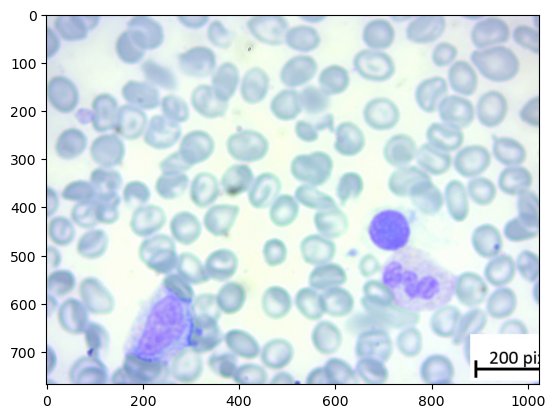

Benign = 94.44502314302238%
[Malignant] Pro-B = 2.314330099743305%
[Malignant] Pre-B = 2.481209903110261%
[Malignant] early Pre-B = 0.7594368541240355%
The predicted image is : Benign


In [12]:
path = r"C:\Users\great\Downloads\archive (7)\Blood cell Cancer [ALL]\Benign\Snap_101 (2).jpg"
img = imread(path)
plt.imshow(img)
plt.show()

img_resize = resize(img, (150, 150, 3))
l = [img_resize.flatten()]

Categories = ['Benign','[Malignant] Pro-B','[Malignant] Pre-B','[Malignant] early Pre-B']

probability = model.predict_proba(l)        
for ind, val in enumerate(Categories):
    print(f'{val} = {probability[0][ind] * 100}%')

print("The predicted image is : " + Categories[model.predict(l)[0]])   

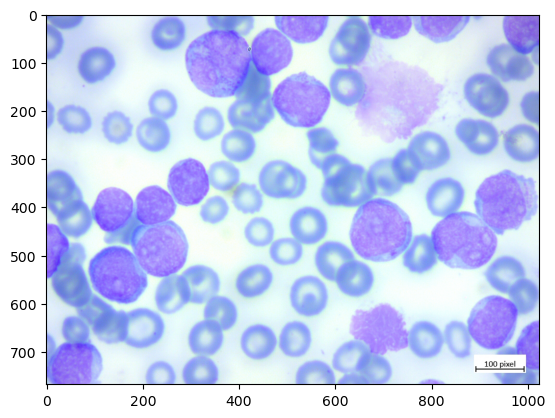

Benign = 2.167327294653414%
[Malignant] Pro-B = 0.45249715632225146%
[Malignant] Pre-B = 80.2529723481473%
[Malignant] early Pre-B = 17.12720320087709%
The predicted image is : [Malignant] Pre-B


In [13]:
path = r"C:\Users\great\Downloads\archive (7)\Blood cell Cancer [ALL]\[Malignant] Pre-B\Snap_456.jpg"
img = imread(path)
plt.imshow(img)
plt.show()

img_resize = resize(img, (150, 150, 3))
l = [img_resize.flatten()]

Categories = ['Benign','[Malignant] Pro-B','[Malignant] Pre-B','[Malignant] early Pre-B']

probability = model.predict_proba(l)        
for ind, val in enumerate(Categories):
    print(f'{val} = {probability[0][ind] * 100}%')

print("The predicted image is : " + Categories[model.predict(l)[0]])   

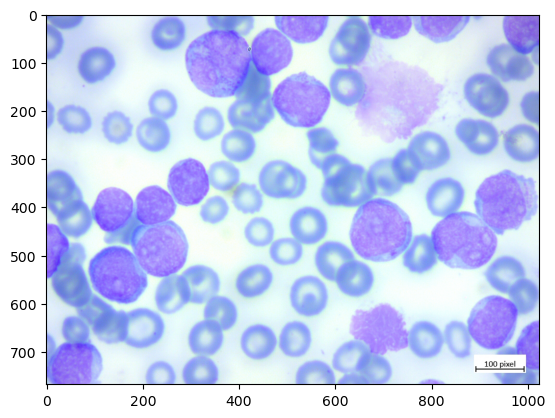

Benign = 2.167327294653414%
[Malignant] Pro-B = 0.45249715632225146%
[Malignant] Pre-B = 80.2529723481473%
[Malignant] early Pre-B = 17.12720320087709%
The predicted image is : [Malignant] Pre-B


In [14]:
path = r"C:\Users\great\Downloads\archive (7)\Blood cell Cancer [ALL]\[Malignant] early Pre-B\Snap_163.jpg"
plt.imshow(img)
plt.show()

img_resize = resize(img, (150, 150, 3))
l = [img_resize.flatten()]

Categories = ['Benign','[Malignant] Pro-B','[Malignant] Pre-B','[Malignant] early Pre-B']

probability = model.predict_proba(l)        
for ind, val in enumerate(Categories):
    print(f'{val} = {probability[0][ind] * 100}%')

print("The predicted image is : " + Categories[model.predict(l)[0]])   

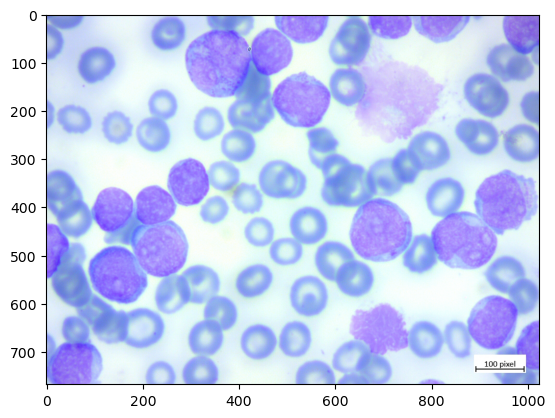

Benign = 2.167327294653414%
[Malignant] Pro-B = 0.45249715632225146%
[Malignant] Pre-B = 80.2529723481473%
[Malignant] early Pre-B = 17.12720320087709%
The predicted image is : [Malignant] Pre-B


In [15]:
path = r"C:\Users\great\Downloads\archive (7)\Blood cell Cancer [ALL]\[Malignant] Pro-B\Snap_321.jpg"
plt.imshow(img)
plt.show()

img_resize = resize(img, (150, 150, 3))
l = [img_resize.flatten()]

Categories = ['Benign','[Malignant] Pro-B','[Malignant] Pre-B','[Malignant] early Pre-B']

probability = model.predict_proba(l)        
for ind, val in enumerate(Categories):
    print(f'{val} = {probability[0][ind] * 100}%')

print("The predicted image is : " + Categories[model.predict(l)[0]])   